# Simple Linear Regression — Salary Prediction

- **Dataset:** `Salary_Data.csv`
- **Feature:** YearsExperience
- **Target:** Salary
- **Model:** `sklearn.linear_model.LinearRegression`

## 1. Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


## 2. Load Dataset

In [21]:
df = pd.read_csv(r'..\datasets\salary_non_linear.csv')

df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,45000.0
2,1.5,36500.0
3,2.0,42000.0
4,2.2,41000.0


In [22]:
df.shape

(30, 2)

## 3. Basic EDA

In [23]:
# Dataset structure
df.info()

# Summary statistics
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76228.100000
std,2.837888,27541.457628
min,1.100000,36500.000000
25%,3.200000,56500.000000
50%,4.700000,67500.000000
75%,7.700000,99500.000000
max,10.500000,125000.000000


In [24]:
df.isnull().sum()

YearsExperience    0
Salary             0
dtype: int64

In [25]:
df.duplicated().sum()

0

In [26]:
# Missing values
print('Missing values:')
print(df.isnull().sum())

# Duplicate rows
print('\nDuplicate rows:', df.duplicated().sum())

# Handle missing values and duplicates if present
df = df.drop_duplicates().dropna().reset_index(drop=True)

print('\nShape after cleaning:', df.shape)

Missing values:
YearsExperience    0
Salary             0
dtype: int64

Duplicate rows: 0

Shape after cleaning: (30, 2)


## 4. Visualization

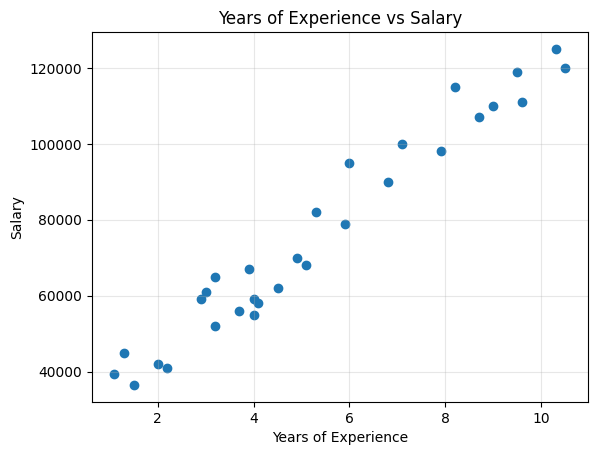

In [27]:
# plt.figure(figsize=(8, 5))
plt.scatter(df['YearsExperience'], df['Salary'])
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Years of Experience vs Salary')
plt.grid(alpha=0.3)
plt.show()

In [9]:
df[['YearsExperience']]

,YearsExperience
0,1.1
1,1.3
2,1.5
3,2.0
4,2.2
5,2.9
6,3.0
7,3.2
8,3.2
9,3.7


In [28]:
df['X2'] = df['YearsExperience'] ** 2

In [29]:
df.head()

,YearsExperience,Salary,X2
0,1.1,39343.0,1.21
1,1.3,45000.0,1.69
2,1.5,36500.0,2.25
3,2.0,42000.0,4.00
4,2.2,41000.0,4.84


## 5. Prepare Features and Target

In [30]:
X = df[['YearsExperience', "X2"]]
y = df['Salary']

print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (30, 2)
y shape: (30,)


In [ ]:
X_train = X.iloc[0:24]
X_test = X.iloc[24:]

y_train = y.iloc[0:24]
y_test = y.iloc[24]

,YearsExperience
0,1.1
1,1.3
2,1.5
3,2.0
4,2.2
5,2.9
6,3.0
7,3.2
8,3.2
9,3.7


In [33]:
np.random.seed(67)
np.random.randint(0, 10, 3)

array([3, 5, 5])

In [43]:
np.random.seed(54)
np.random.rand()

0.42018296714077386

In [47]:
l = [4, 65, 2]
np.random.shuffle(l)
l

[2, 65, 4]

## 6. Train-Test Split

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Training samples:', len(X_train))
print('Testing samples:', len(X_test))

Training samples: 24
Testing samples: 6


## 7. Train Linear Regression Model

In [32]:
model = LinearRegression()
model.fit(X_train, y_train)

print('Coefficient:', model.coef_)
print('Intercept:', model.intercept_)

Coefficient: [8812.93932551   58.18525626]
Intercept: 26727.559977904064


## 8. Model Evaluation

In [33]:
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f'R² Score: {r2:.4f}')
print(f'Mean Absolute Error: {mae:.2f}')
print(f'Mean Squared Error: {mse:.2f}')

R² Score: 0.8894
Mean Absolute Error: 6605.45
Mean Squared Error: 55878009.61


## 9. Regression Line — Training Data

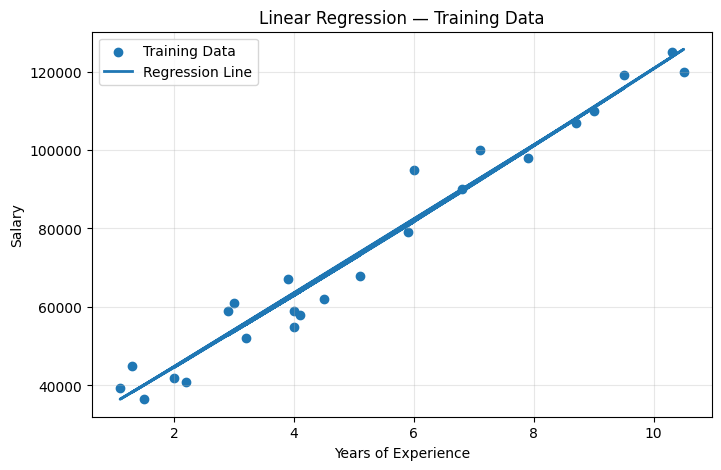

In [34]:
plt.figure(figsize=(8, 5))
plt.scatter(X_train['YearsExperience'], y_train, label='Training Data')
plt.plot(X_train['YearsExperience'], model.predict(X_train), linewidth=2, label='Regression Line')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Linear Regression — Training Data')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 10. Regression Line — Testing Data

ValueError: x and y must be the same size

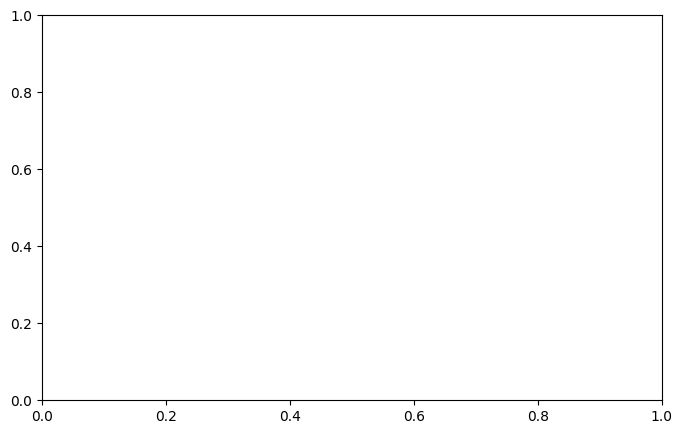

In [35]:
plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test, label='Testing Data')
plt.plot(X_test, y_pred, linewidth=1, label='Regression Line', marker='x',)
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Linear Regression — Testing Data')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [58]:
X_test

,YearsExperience
27,9.6
15,4.9
23,8.2
17,5.3
8,3.2
9,3.7


In [57]:
y_test

27    112635.0
15     67938.0
23    113812.0
17     83088.0
8      64445.0
9      57189.0
Name: Salary, dtype: float64

## 11. Save the Trained Model

In [59]:
model_path = 'salary_linear_regression.joblib'
joblib.dump(model, model_path)

print(f'Model saved to: {model_path}')

Model saved to: salary_linear_regression.joblib


## 12. Load Model and Make a Prediction

In [ ]:
loaded_model = joblib.load('salary_linear_regression.joblib')

years = 8
predicted_salary = loaded_model.predict([[years]])[0]

print(f'Predicted salary for {years} years of experience: {predicted_salary:,.2f}')

In [36]:
x = np.arange(1, 51)

In [38]:
x2 = x**2

In [37]:
x

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50])

In [39]:
y = 0.3*x + 2.4*x2 + 10

In [40]:
x.shape

(50,)

In [41]:
y.shape

(50,)

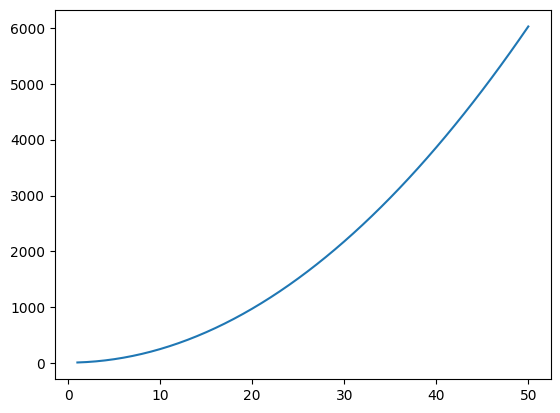

In [42]:
plt.plot(x, y)